<a href="https://colab.research.google.com/github/sevaradevoloper/machine-learning-class-work/blob/main/Houseprice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
!pip install opendatasets legacy-cgi
import opendatasets as od
od.download("https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data")

Skipping, found downloaded files in "./house-prices-advanced-regression-techniques" (use force=True to force download)


In [73]:
import pandas as pd
df = pd.read_csv("/content/house-prices-advanced-regression-techniques/train.csv")
df


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [74]:
#EDA

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Kaggle **House Prices** datasetidagi barcha 81 ta ustun va uning ma'lumot turlari tarjimasi:

---

**0. Id** — Har bir uyning unikal identifikator raqami *(Sonli / Integer)*

**1. MSSubClass** — Uyning turi va necha qavatli ekanligi kodi *(Sonli / Integer)*

**2. MSZoning** — Uy joylashgan hududning umumiy zonasi *(Kategorik / Object)*

**3. LotFrontage** — Uyning yo'lga tutashgan old qismining uzunligi (funtda) *(Sonli / Float)*

**4. LotArea** — Uy uchastkasining umumiy maydoni (kvadrat funtda) *(Sonli / Integer)*

**5. Street** — Uyga olib boruvchi yo'l turi (Asfalt yoki Shag'al) *(Kategorik / Object)*

**6. Alley** — Uyga kirish xiyoboni/yo'lagi turi *(Kategorik / Object)*

**7. LotShape** — Uy uchastkasining shakli va geometriyasi *(Kategorik / Object)*

**8. LandContour** — Uy joylashgan yerning tekisligi/relyefi *(Kategorik / Object)*

**9. Utilities** — Mavjud kommunal xizmatlar (Gaz, Elektr, Suv, Kanalizatsiya) *(Kategorik / Object)*

**10. LotConfig** — Uchastkaning joylashuv konfiguratsiyasi (Burchakda, Ichkarida va h.k.) *(Kategorik / Object)*

**11. LandSlope** — Yer maydonining qiyaligi/nishabligi *(Kategorik / Object)*

**12. Neighborhood** — Uy joylashgan micro-tuman/mahalla nomi *(Kategorik / Object)*

**13. Condition1** — Asosiy yo'l yoki temir yo'lga yaqinligi/sharoiti *(Kategorik / Object)*

**14. Condition2** — Qo'shimcha yo'l yoki sharoitlarga yaqinligi *(Kategorik / Object)*

**15. BldgType** — Uyning bino turi (Bir oilalik, Bloklangan va h.k.) *(Kategorik / Object)*

**16. HouseStyle** — Uyning me'moriy uslubi va qavatlar tuzilishi *(Kategorik / Object)*

**17. OverallQual** — Uyning umumiy materiali va pardozlash sifati (1-10 baho) *(Sonli / Integer)*

**18. OverallCond** — Uyning umumiy hozirgi holati bahosi (1-10 baho) *(Sonli / Integer)*

**19. YearBuilt** — Uy qurilgan yil *(Sonli / Integer)*

**20. YearRemodAdd** — Uy ta'mirlangan (rekonstruksiya qilingan) yil *(Sonli / Integer)*

**21. RoofStyle** — Tomning shakli va uslubi *(Kategorik / Object)*

**22. RoofMatl** — Tom yopilgan material turi *(Kategorik / Object)*

**23. Exterior1st** — Uy tashqi devorining asosiy qoplamasi *(Kategorik / Object)*

**24. Exterior2nd** — Uy tashqi devorining ikkinchi darajali qoplamasi *(Kategorik / Object)*

**25. MasVnrType** — Tashqi devordagi g'isht/tosh qoplama turi *(Kategorik / Object)*

**26. MasVnrArea** — Tashqi devordagi g'isht/tosh qoplama maydoni *(Sonli / Float)*

**27. ExterQual** — Tashqi fasad materialining sifati *(Kategorik / Object)*

**28. ExterCond** — Tashqi fasad materialining hozirgi holati *(Kategorik / Object)*

**29. Foundation** — Uy poydevorining turi (Beton, G'isht va h.k.) *(Kategorik / Object)*

**30. BsmtQual** — Yerto'laning balandligi va sifati *(Kategorik / Object)*

**31. BsmtCond** — Yerto'laning umumiy holati va namlik darajasi *(Kategorik / Object)*

**32. BsmtExposure** — Yerto'laning yer ustiga chiqish yoki deraza darajasi *(Kategorik / Object)*

**33. BsmtFinType1** — Yerto'laning asosiy tayyorlangan/yashash uchun moslangan qismi *(Kategorik / Object)*

**34. BsmtFinSF1** — Yerto'laning 1-turdagi tayyor qismi maydoni *(Sonli / Integer)*

**35. BsmtFinType2** — Yerto'laning ikkinchi darajali tayyorlangan qismi *(Kategorik / Object)*

**36. BsmtFinSF2** — Yerto'laning 2-turdagi tayyor qismi maydoni *(Sonli / Integer)*

**37. BsmtUnfSF** — Yerto'laning ta'mirlanmagan/xom qismi maydoni *(Sonli / Integer)*

**38. TotalBsmtSF** — Yerto'laning umumiy maydoni *(Sonli / Integer)*

**39. Heating** — Isitish tizimining turi *(Kategorik / Object)*

**40. HeatingQC** — Isitish tizimining sifati va samaradorligi *(Kategorik / Object)*

**41. CentralAir** — Markaziy konditsioner tizimi mavjudligi (Y/N) *(Kategorik / Object)*

**42. Electrical** — Elektr tizimining turi *(Kategorik / Object)*

**43. 1stFlrSF** — Birinchi qavatning umumiy maydoni *(Sonli / Integer)*

**44. 2ndFlrSF** — Ikkinchi qavatning umumiy maydoni *(Sonli / Integer)*

**45. LowQualFinSF** — Past sifatli ta'mirlangan maydon (barcha qavatlar bo'yicha) *(Sonli / Integer)*

**46. GrLivArea** — Yer ustidagi umumiy yashash maydoni *(Sonli / Integer)*

**47. BsmtFullBath** — Yerto'ladagi to'liq xammomlar soni *(Sonli / Integer)*

**48. BsmtHalfBath** — Yerto'ladagi yarim xammomlar (hojatxonalar) soni *(Sonli / Integer)*

**49. FullBath** — Yer ustidagi to'liq xammomlar soni *(Sonli / Integer)*

**50. HalfBath** — Yer ustidagi yarim xammomlar (hojatxonalar) soni *(Sonli / Integer)*

**51. BedroomAbvGr** — Yer ustidagi yotoqxonalar soni *(Sonli / Integer)*

**52. KitchenAbvGr** — Yer ustidagi oshxonalar soni *(Sonli / Integer)*

**53. KitchenQual** — Oshxonaning sifati va jihozlanishi *(Kategorik / Object)*

**54. TotRmsAbvGrd** — Yer ustidagi umumiy xonalar soni (xammom va oshxonadan tashqari) *(Sonli / Integer)*

**55. Functional** — Uyning umumiy funksionalligi va zararlanganlik darajasi *(Kategorik / Object)*

**56. Fireplaces** — Kaminlar (O'choqlar) soni *(Sonli / Integer)*

**57. FireplaceQu** — Kaminning sifati va ishlash holati *(Kategorik / Object)*

**58. GarageType** — Garajning joylashuvi va turi *(Kategorik / Object)*

**59. GarageYrBlt** — Garaj qurilgan yil *(Sonli / Float)*

**60. GarageFinish** — Garajning ichki pardozi holati *(Kategorik / Object)*

**61. GarageCars** — Garajga sig'adigan mashinalar soni *(Sonli / Integer)*

**62. GarageArea** — Garajning kvadrat funtdagi maydoni *(Sonli / Integer)*

**63. GarageQual** — Garajning sifati *(Kategorik / Object)*

**64. GarageCond** — Garajning hozirgi holati *(Kategorik / Object)*

**65. PavedDrive** — Garajga olib boruvchi yo'lning asfaltlanganlik darajasi *(Kategorik / Object)*

**66. WoodDeckSF** — Yog'ochli ayvon/osma platforma maydoni *(Sonli / Integer)*

**67. OpenPorchSF** — Ochiq ayvon maydoni *(Sonli / Integer)*

**68. EnclosedPorch** — Yopiq ayvon maydoni *(Sonli / Integer)*

**69. 3SsnPorch** — Uch mavsumiy (bahor-yoz-kuz) ayvon maydoni *(Sonli / Integer)*

**70. ScreenPorch** — To'r bilan o'ralgan ayvon maydoni *(Sonli / Integer)*

**71. PoolArea** — Basseyn maydoni *(Sonli / Integer)*

**72. PoolQC** — Basseynning sifati *(Kategorik / Object)*

**73. Fence** — Devor/Tsiq devor sifati va turi *(Kategorik / Object)*

**74. MiscFeature** — Boshqa ustunlarda yo'q qo'shimcha imkoniyatlar (Masalan: Lift, Tennis korti) *(Kategorik / Object)*

**75. MiscVal** — Qo'shimcha imkoniyatlarning qiymati/narxi *(Sonli / Integer)*

**76. MoSold** — Uy sotilgan oy *(Sonli / Integer)*

**77. YrSold** — Uy sotilgan yil *(Sonli / Integer)*

**78. SaleType** — Sotuv turi (Kredit, Naqd, Yangi bino va h.k.) *(Kategorik / Object)*

**79. SaleCondition** — Sotish sharti (Oddiy, Normal bo'lmagan sotuv, Bank orqali va h.k.) *(Kategorik / Object)*

**80. SalePrice** — Uyning sotilish narxi (Nishon ustun / Target variable) *(Sonli / Integer)*

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV, learning_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

In [78]:
# TARGET = "SalePrice"


In [79]:
# Faqat Id ustunini o'chiramiz, chunki u shunchaki tartib raqami
df = df.drop(columns=['Id'])

In [80]:
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [81]:
# bosh qiymatlarni toldiramiz va dublicatelarni olib tashlaymiz:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
print("\n--- Eng ko'p bo'sh qiymatga ega ustunlar ---")
print(missing_pct[missing_pct > 0].head(20))

# endi ularni toldiramiz va qayta tekshiramiz:



--- Eng ko'p bo'sh qiymatga ega ustunlar ---
PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageType       5.547945
GarageFinish     5.547945
GarageCond       5.547945
GarageYrBlt      5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtFinType1     2.534247
BsmtCond         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


In [82]:
# Target ustunni tekshiramiz,tuzatamiz,va boshqa ustunlar bn bogliqliqlarni koramiz

In [83]:
print(f"\nSalePrice skewness: {df["SalePrice"].skew():.3f}")


SalePrice skewness: 1.883


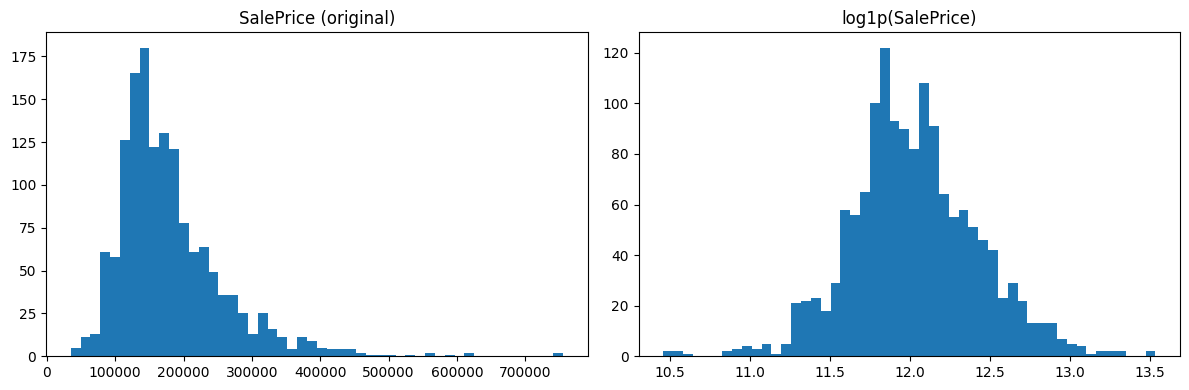

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["SalePrice"], bins=50)
axes[0].set_title("SalePrice (original)")
axes[1].hist(np.log1p(df["SalePrice"]), bins=50)
axes[1].set_title("log1p(SalePrice)")
plt.tight_layout()
plt.savefig("eda_target_distribution.png")
plt.show()


--- SalePrice bilan eng yuqori korrelyatsiya ---
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


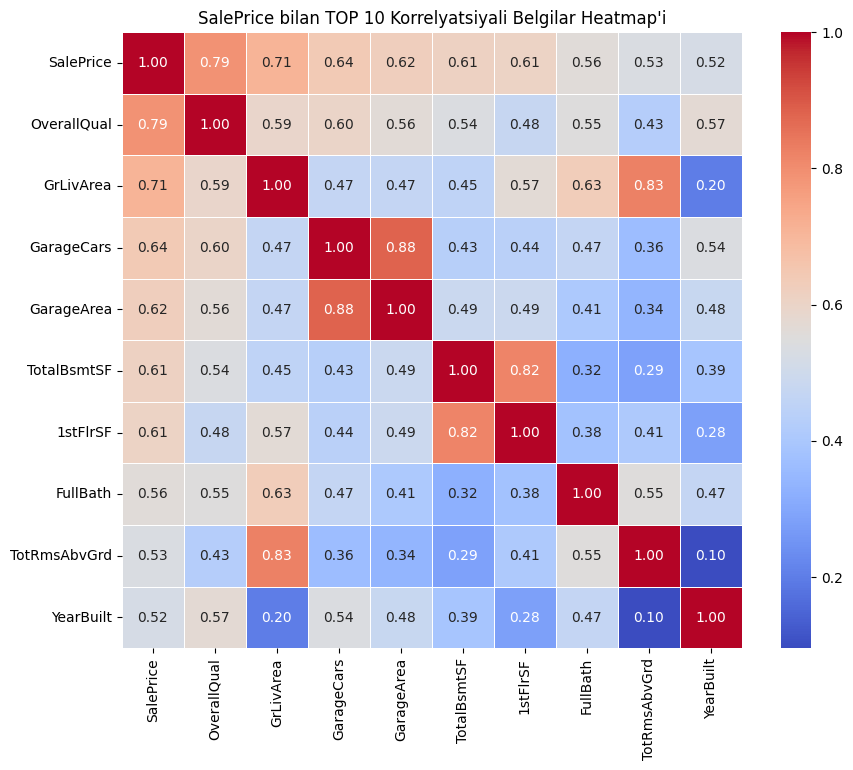

In [85]:
# Eng yuqori korrelyatsiyaga ega belgilar
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()["SalePrice"].sort_values(ascending=False)
print("\n--- SalePrice bilan eng yuqori korrelyatsiya ---")
print(corr.head(11))  # birinchisi SalePrice'ning o'zi

# 1. SalePrice bilan eng yuqori korrelyatsiyaga ega 10 ta ustun nomini olish
top_corr_features = corr.head(10).index

# 2. Faqat shu ustunlarning korrelyatsiya matritsasini hisoblash
top_corr_matrix = numeric_df[top_corr_features].corr()

# 3. Heatmap vizualizatsiyasi
plt.figure(figsize=(10, 8))
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("SalePrice bilan TOP 10 Korrelyatsiyali Belgilar Heatmap'i")
plt.show()

3 ta xulosani yozib qo'ying:

Multicollinearity (Ustunlarning bir-birini takrorlashi):
Heatmap'da GarageCars va GarageArea (yoki GrLivArea va TotRmsAbvGrd, 1stFlrSF va TotalBsmtSF) bir-biri bilan 0.80+ juda yuqori korrelyatsiyada turganini ko'rasiz.

Xulosa: Bular bir xil ma'lumotni ikkita ustunda berayapti (masalan garajdagi mashina soni va garaj maydoni). Ba'zi sodda modellar buning uchun chalg'iydi, lekin Random Forest bunga chidamli.

Eng kuchli Signal (Predictive Power):
OverallQual (Uyning umumiy sifati) va GrLivArea (Yer usti yashash maydoni) SalePrice bilan eng yuqori korrelyatsiyani (0.70 - 0.80) beradi.

Xulosa: Uy narxini belgilaydigan shoh ustunlar aynan shular.

Outliers (G'alati qiymatlar) xavfi:
GrLivArea judayam katta bo'lib, lekin narxi arzon bo'lgan g'alati uylar (Outlier'lar) bo'lishi mumkin. Keyingi qadamda buni Scatter plot'da tozalaymiz.

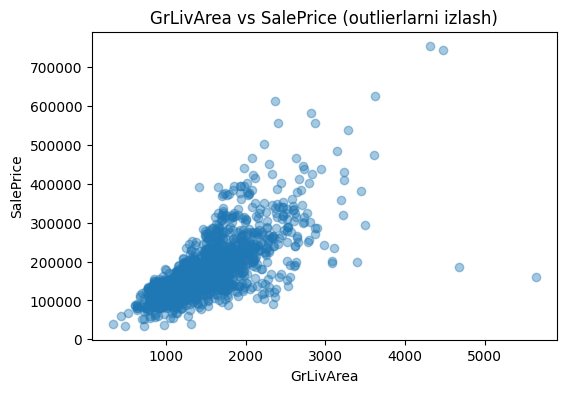

In [86]:
#  Outlier'larni ko'rish uchun scatter (masalan, GrLivArea vs SalePrice)
plt.figure(figsize=(6, 4))
plt.scatter(df["GrLivArea"], df["SalePrice"], alpha=0.4)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("GrLivArea vs SalePrice (outlierlarni izlash)")
plt.savefig("eda_grlivarea_vs_price.png")
plt.show()

# Grafik tahlili Xulosa:
# Umumiy trend (To'g'ri bog'liqlik): Maydon (GrLivArea) kattalashgani sari narx (SalePrice) oshib bormoqda.

# Anomal nuqtalar (Outliers):
# Ongdagi 2 ta nuqta: Maydoni GrLivArea > 4000 va narxi SalePrice < 300000.
# Bular modelning chiziqli/regressiya mantig'ini va daraxtlar bo'linishini chalg'itadi
# (Overfitting'ga sabab bo'ladi).
# Yuqoridagi 2 ta qimmat nuqta: Maydoni 4000 ga yaqin va narxi $700,000 dan yuqori.
# Lekin ular umumiy trendga mos tushgani uchun ularni tegmasdan qoldirish mumkin.

In [87]:
#  kengi qadam Train va testga bolib olish undan song f engineering,encoding scalinglar.

In [88]:
# 1. Target (y) va Features (X) ajratish
X = df.drop(columns=['SalePrice'])
y = np.log1p(df['SalePrice'])  # Log-transformatsiya (Data skewness'ni yo'qotish uchun)

# 2. Train va Test'ga bo'lish (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train hajmi: {X_train.shape}")
print(f"X_test hajmi:  {X_test.shape}")

X_train hajmi: (1168, 79)
X_test hajmi:  (292, 79)


In [89]:
# A. Categorical None/0 bilan to'ldirish (Statistikaga bog'liq emas - har ikkala setga bir xil)
none_cols = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
             'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
             'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']
for col in none_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna('None')
        X_test[col] = X_test[col].fillna('None')

zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea']
for col in zero_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna(0)
        X_test[col] = X_test[col].fillna(0)

# B. FAQAT X_TRAIN DAN MEDIANA VA MODE HISOBLASH (Leakage yo'q qilinadi!)
# LotFrontage: Faqat X_train bo'yicha Neighborhood medianasi olinadi
lot_frontage_medians = X_train.groupby('Neighborhood')['LotFrontage'].median()

# X_train va X_test ga FAQAT X_train medianalarini qo'llaymiz
X_train['LotFrontage'] = X_train.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
X_test['LotFrontage'] = X_test.apply(
    lambda row: lot_frontage_medians.get(row['Neighborhood'], X_train['LotFrontage'].median())
    if pd.isna(row['LotFrontage']) else row['LotFrontage'], axis=1
)

# Electrical va MSZoning: Faqat X_train dagi Eng ko'p uchragan qiymat (Mode)
electrical_mode = X_train['Electrical'].mode()[0] if 'Electrical' in X_train.columns else 'SBrkr'
mszoning_mode = X_train['MSZoning'].mode()[0] if 'MSZoning' in X_train.columns else 'RL'

X_train['Electrical'] = X_train['Electrical'].fillna(electrical_mode)
X_test['Electrical'] = X_test['Electrical'].fillna(electrical_mode)

X_train['MSZoning'] = X_train['MSZoning'].fillna(mszoning_mode)
X_test['MSZoning'] = X_test['MSZoning'].fillna(mszoning_mode)


**Feature Engineering va Encoding**

In [90]:

# A. Train va Test uchun Yangi Mantiqiy Ustunlar Yaratish (Feature Engineering)
for dataset in [X_train, X_test]:
    # 1. Uyning umumiy haqiqiy maydoni (Yerto'la + 1-qavat + 2-qavat)
    dataset['TotalSF'] = dataset['TotalBsmtSF'] + dataset['1stFlrSF'] + dataset['2ndFlrSF']

    # 2. Uyning umumiy vannaxonalar soni
    dataset['TotalBaths'] = dataset['FullBath'] + (0.5 * dataset['HalfBath']) + dataset['BsmtFullBath'] + (0.5 * dataset['BsmtHalfBath'])

    # 3. Uyning yoshi (Sotilgan yili - Qurilgan yili)
    dataset['HouseAge'] = dataset['YrSold'] - dataset['YearBuilt']

    # 4. Ta'mirlanganidan beri o'tgan yillar
    dataset['RemodAge'] = dataset['YrSold'] - dataset['YearRemodAdd']

    # 5. Kamin, Garaj va Yerto'la bor-yo'qligini bildiruvchi indikatorlar (0/1)
    dataset['HasFireplace'] = (dataset['Fireplaces'] > 0).astype(int)
    dataset['HasGarage'] = (dataset['GarageArea'] > 0).astype(int)
    dataset['HasBsmt'] = (dataset['TotalBsmtSF'] > 0).astype(int)


# B. Categorical Encoding (One-Hot Encoding)
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# C. Alignment (Train va Test ustunlarini 100% tenglashtirish)
# Train'da bor lekin Test'da yo'q ustunlarni 0 bilan to'ldiradi
X_train_final, X_test_final = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

print("✅ Feature Engineering va Encoding muvaffaqiyatli yakunlandi!")
print(f"X_train_final shakli: {X_train_final.shape}")
print(f"X_test_final shakli:  {X_test_final.shape}")

✅ Feature Engineering va Encoding muvaffaqiyatli yakunlandi!
X_train_final shakli: (1168, 263)
X_test_final shakli:  (292, 263)


**Scaling shart emas**

Baseline OOB R2 score: 0.8675

--- Top 15 muhim belgilar ---
OverallQual     0.390881
TotalSF         0.365229
GrLivArea       0.013247
LotArea         0.012236
GarageCars      0.012062
GarageArea      0.011856
CentralAir_Y    0.011652
TotalBaths      0.011417
BsmtFinSF1      0.009356
RemodAge        0.009217
HouseAge        0.009070
YearBuilt       0.008919
OverallCond     0.008277
GarageYrBlt     0.007500
BsmtUnfSF       0.006629
dtype: float64


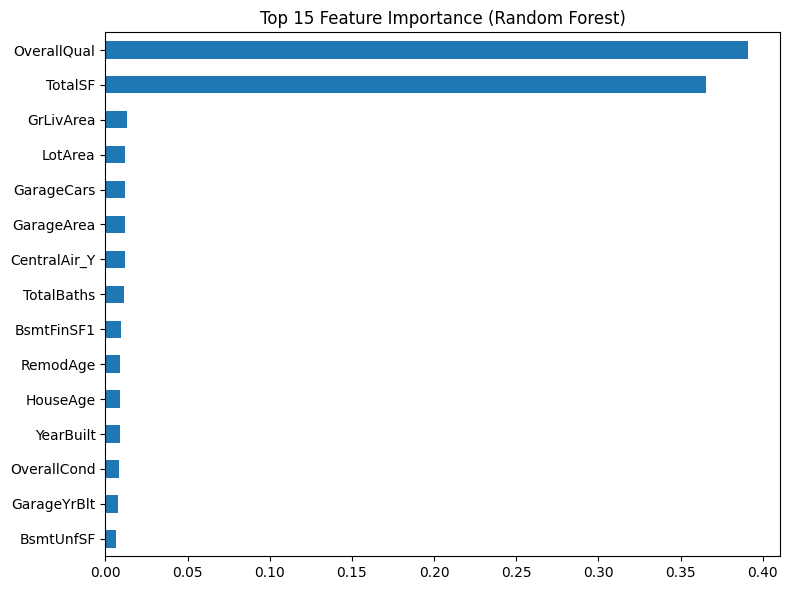

In [91]:
# endi Train qilamiz:

from sklearn.ensemble import RandomForestRegressor

rf_baseline = RandomForestRegressor(
    n_estimators=300,
    oob_score=True,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train_final, y_train)

print(f"Baseline OOB R2 score: {rf_baseline.oob_score_:.4f}")

feat_imp = pd.Series(
    rf_baseline.feature_importances_,
    index=X_train_final.columns
).sort_values(ascending=False)

print("\n--- Top 15 muhim belgilar ---")
print(feat_imp.head(15))

plt.figure(figsize=(8, 6))
feat_imp.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

Train R2: 0.9822 | Test R2: 0.8824 | OOB R2: 0.8675


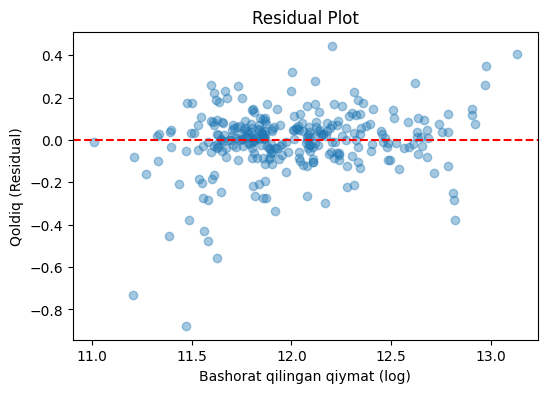

In [92]:
from sklearn.metrics import r2_score

train_pred = rf_baseline.predict(X_train_final)
test_pred = rf_baseline.predict(X_test_final)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f} | OOB R2: {rf_baseline.oob_score_:.4f}")

# Residual plot
residuals = y_test - test_pred
plt.figure(figsize=(6, 4))
plt.scatter(test_pred, residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Bashorat qilingan qiymat (log)")
plt.ylabel("Qoldiq (Residual)")
plt.title("Residual Plot")
plt.show()

In [93]:
from sklearn.metrics import r2_score

train_pred = rf_baseline.predict(X_train_final)
test_pred = rf_baseline.predict(X_test_final)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print(f"Train R2: {train_r2:.4f}")
print(f"Test R2:  {test_r2:.4f}")
print(f"OOB R2:   {rf_baseline.oob_score_:.4f}")
print(f"Train-Test farqi: {train_r2 - test_r2:.4f}")

Train R2: 0.9822
Test R2:  0.8824
OOB R2:   0.8675
Train-Test farqi: 0.0998


In [ ]:
# GridSearch 5 ta bolimchaga bolib qasyi giperparamter yaxshiligini aniqlab beradi:


In [94]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [None, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5, 0.8],
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,                 # 20 ta tasodifiy kombinatsiya sinaladi
    cv=5,                      # 5-fold cross-validation
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_final, y_train)

print("Eng yaxshi parametrlar:", search.best_params_)
print("Eng yaxshi CV RMSE (log-space):", -search.best_score_)

best_model = search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Eng yaxshi parametrlar: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}
Eng yaxshi CV RMSE (log-space): 0.13895652536115444


In [95]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. Eng yaxshi model bilan X_test_final bo'yicha bashorat qilish (log-scale)
y_pred_log = best_model.predict(X_test_final)

# 2. Haqiqiy va prediktsiya qiymatlarini log-scale'dan qaytarib DOLLAR ($) ga o'tkazish
y_test_dollar = np.expm1(y_test)
y_pred_dollar = np.expm1(y_pred_log)

# 3. Yakuniy metrikalarni hisoblash
final_rmse = np.sqrt(mean_squared_error(y_test_dollar, y_pred_dollar))
final_mae = mean_absolute_error(y_test_dollar, y_pred_dollar)
final_r2 = r2_score(y_test_dollar, y_pred_dollar)

print("=== YAKUNIY OPTIMAL MODEL METRIKALARI ===")
print(f"R² Score: {final_r2:.4f}")
print(f"MAE:      ${final_mae:,.2f}")
print(f"RMSE:     ${final_rmse:,.2f}")

=== YAKUNIY OPTIMAL MODEL METRIKALARI ===
R² Score: 0.8796
MAE:      $17,018.21
RMSE:     $30,388.75


/tmp/ipykernel_593/2196136448.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp.values, y=feature_imp.index, palette="viridis")


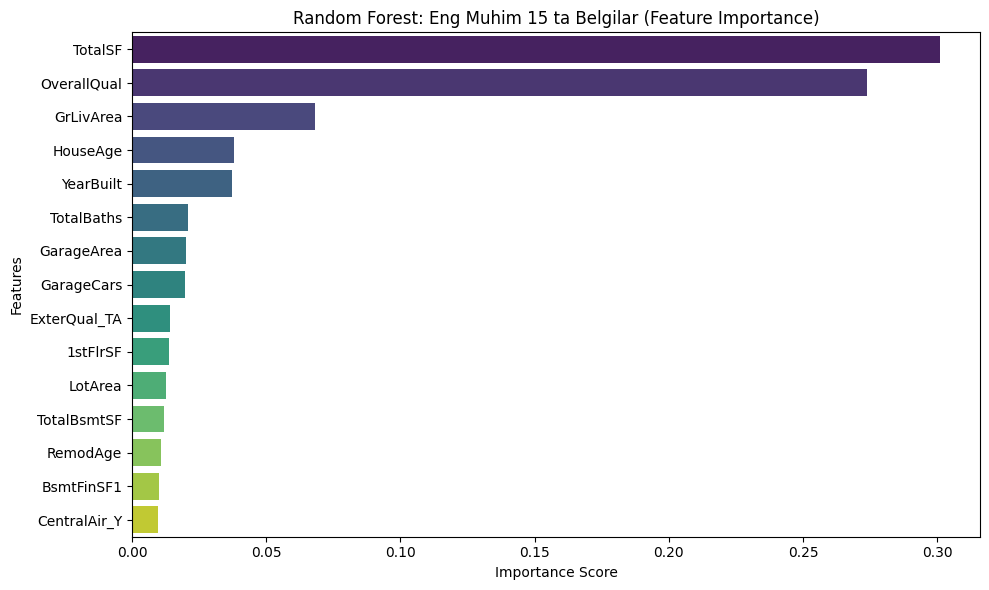

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance olish
importances = best_model.feature_importances_
feature_names = X_train_final.columns

# Top 15 belgini saralash
feature_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

# Vizualizatsiya
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp.values, y=feature_imp.index, palette="viridis")
plt.title("Random Forest: Eng Muhim 15 ta Belgilar (Feature Importance)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

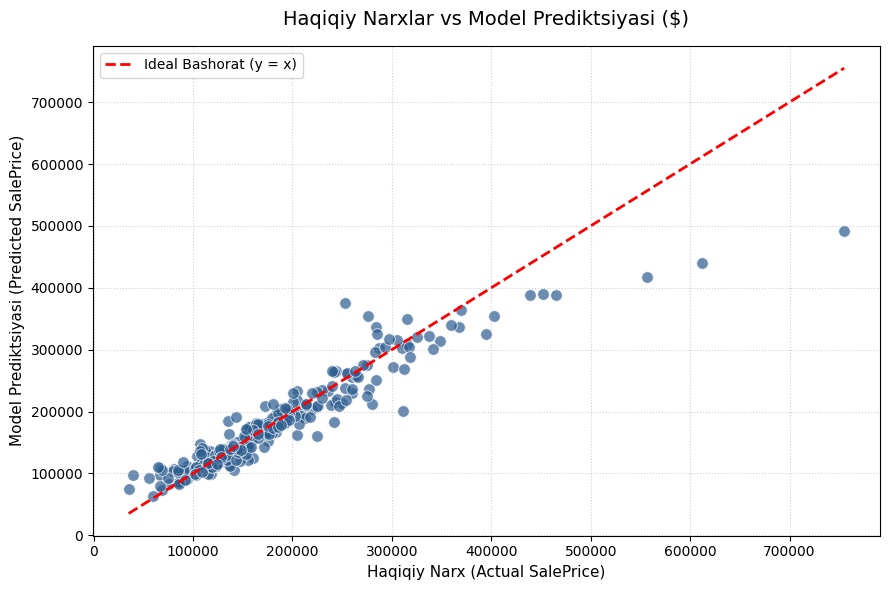

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot o'lchami va uslubi
plt.figure(figsize=(9, 6))

# Haqiqiy va Prediktsiya narxlarini solishtirish
sns.scatterplot(x=y_test_dollar, y=y_pred_dollar, alpha=0.7, color='#2b5c8f', edgecolor='w', s=70)

# Ideal (100% aniq) bashorat chizig'i (y = x)
max_val = max(y_test_dollar.max(), y_pred_dollar.max())
min_val = min(y_test_dollar.min(), y_pred_dollar.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Bashorat (y = x)')

# Grafik bezaqlari
plt.title("Haqiqiy Narxlar vs Model Prediktsiyasi ($)", fontsize=14, pad=15)
plt.xlabel("Haqiqiy Narx (Actual SalePrice)", fontsize=11)
plt.ylabel("Model Prediktsiyasi (Predicted SalePrice)", fontsize=11)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()